# Probabilistic Backpropagation (PBP)

**Probabilistic Backpropagation (PBP)** is a scalable method for training Bayesian neural networks,
introduced by Hernández-Lobato and Adams (2015). Unlike standard neural networks that learn a single
point estimate for each weight, PBP maintains a full *probability distribution* over the weights,
enabling the network to quantify the **uncertainty** in its predictions.

#### Key ideas

1. **Approximate posterior**: Each weight $w$ is approximated by a Gaussian distribution
   $q(w) = \mathcal{N}(m_w,\, v_w)$. The parameters $(m_w, v_w)$ are updated during training.

2. **Assumed Density Filtering (ADF)**: PBP processes the training data one example at a time.
   For each data point, it computes the exact posterior factor (which is intractable in general)
   and then projects it back onto the Gaussian family — a procedure known as *moment matching*.

3. **Prior refinement**: After a full pass through the dataset, the prior is updated
   (refined) to better match the current posterior, and training continues for several epochs.

4. **Predictive distribution**: At test time, the learned Gaussian posteriors are propagated
   through the network to produce a predictive mean $\mu$ and variance $\sigma^2$ for each input.
   Additionally, the model estimates the observation noise variance $\sigma_{\text{noise}}^2$.

This notebook demonstrates PBP on a simple 1-D regression task: learning the function
$y(x) = \sin(\pi x)$ from noisy observations. **All code is self-contained** — no external
package imports beyond standard scientific Python libraries.

### 1. Initial Setup

In [7]:
from __future__ import annotations

import math
import sys
from collections.abc import Sequence
from statistics import NormalDist
from typing import Iterable

import numpy as np
import matplotlib.pyplot as plt
import pytensor
import pytensor.tensor as T
from pydantic import BaseModel, ConfigDict, Field, computed_field, field_serializer, field_validator, model_validator
from typing_extensions import Literal

### 2. Dataset Generation

A synthetic 1-D regression dataset is constructed:

- **Target function**: $y(x) = \sin(\pi x)$, which completes one full period over $[-1, 1]$.
- **Training set**: 400 equally-spaced points with additive Gaussian noise ($\sigma = 0.1$).
- **Validation set**: 300 noise-free points used to evaluate predictive quality.

The noise level is intentionally small so that the underlying signal is clearly visible,
while still giving the model something non-trivial to learn.

In [8]:
N_train, N_val = 400, 300
sigma_noise = 0.1

np.random.seed(7)


def f_wave(x: np.ndarray) -> np.ndarray:
    return np.sin(np.pi * x)


x_train = np.linspace(-1.0, 1.0, N_train, dtype=np.float64).reshape(-1, 1)
noise = np.random.randn(*x_train.shape).astype(np.float64) * sigma_noise
y_train = f_wave(x_train) + noise

x_val = np.linspace(-1.0, 1.0, N_val, dtype=np.float64).reshape(-1, 1)
y_val = f_wave(x_val)

### 2.1 Dataset Visualization

The plot below shows the clean validation curve alongside the noisy training samples.

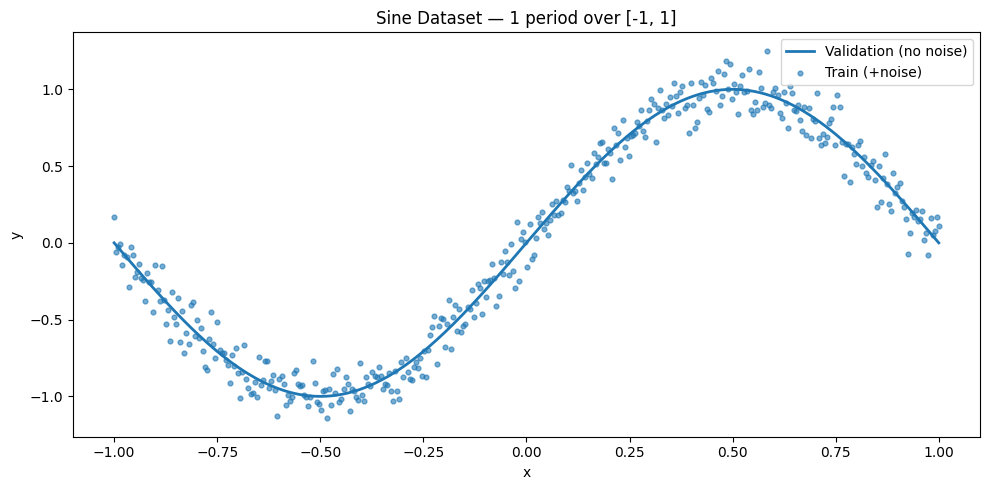

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(x_val, y_val, "-", label="Validation (no noise)", linewidth=2)
plt.scatter(x_train, y_train, s=12, alpha=0.6, label="Train (+noise)")
plt.legend()
plt.title("Sine Dataset — 1 period over [-1, 1]")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

---

## Part A — PBP Core Engine

The following sections define the core PBP implementation from scratch.
The engine is built bottom-up in four layers:

| Component | Role |
|-----------|------|
| **Prior** | Initializes and refines the prior distribution over weights. |
| **Network Layer** | Propagates Gaussian means/variances through a single layer (with ReLU activation). |
| **Network** | Composes layers, computes the marginal likelihood $\log Z$, and generates parameter updates. |
| **PBP** | Orchestrates Assumed Density Filtering passes and prior refinement across epochs. |
| **PBP_net** | High-level wrapper that handles data normalization, training, and prediction. |

### 3. Prior

The `Prior` class manages the prior distribution over network weights and observation noise.

In PBP the prior on each weight $w_{jk}$ is a Gaussian whose variance is itself governed by
a Gamma distribution: $p(w_{jk} \mid \tau) = \mathcal{N}(0, 1/\tau)$ with
$p(\tau) = \text{Gamma}(a_w, b_w)$.  Similarly, the observation noise precision follows
a Gamma prior.

Key methods:

- **`get_initial_params`**: Returns the initial weight means (randomly sampled, scaled by
  $1/\sqrt{n_{\text{in}}+1}$) and variances (from the prior).
- **`refine_prior`**: After one full ADF pass over the data, the prior factors are updated
  using cavity distributions (posterior with the prior factor removed). This improves the
  match between prior and posterior on subsequent passes.

In [10]:
class Prior:
    def __init__(self, layer_sizes, var_targets):
        n_samples = 3.0
        v_observed = 1.0
        self.a_w = 2.0 * n_samples
        self.b_w = 2.0 * n_samples * v_observed

        a_sigma = 2.0 * n_samples
        b_sigma = 2.0 * n_samples * var_targets

        self.a_sigma_hat_nat = a_sigma - 1
        self.b_sigma_hat_nat = -b_sigma

        self.rnd_m_w = []
        self.m_w_hat_nat = []
        self.v_w_hat_nat = []
        self.a_w_hat_nat = []
        self.b_w_hat_nat = []
        for size_out, size_in in zip(layer_sizes[1:], layer_sizes[:-1]):
            self.rnd_m_w.append(
                1.0 / np.sqrt(size_in + 1) * np.random.randn(size_out, size_in + 1)
            )
            self.m_w_hat_nat.append(np.zeros((size_out, size_in + 1)))
            self.v_w_hat_nat.append(
                (self.a_w - 1) / self.b_w * np.ones((size_out, size_in + 1))
            )
            self.a_w_hat_nat.append(np.zeros((size_out, size_in + 1)))
            self.b_w_hat_nat.append(np.zeros((size_out, size_in + 1)))

    def get_initial_params(self):
        m_w = []
        v_w = []
        for i in range(len(self.rnd_m_w)):
            m_w.append(self.rnd_m_w[i])
            v_w.append(1.0 / self.v_w_hat_nat[i])
        return {
            "m_w": m_w,
            "v_w": v_w,
            "a": self.a_sigma_hat_nat + 1,
            "b": -self.b_sigma_hat_nat,
        }

    def get_params(self):
        m_w = []
        v_w = []
        for i in range(len(self.rnd_m_w)):
            m_w.append(self.m_w_hat_nat[i] / self.v_w_hat_nat[i])
            v_w.append(1.0 / self.v_w_hat_nat[i])
        return {
            "m_w": m_w,
            "v_w": v_w,
            "a": self.a_sigma_hat_nat + 1,
            "b": -self.b_sigma_hat_nat,
        }

    def refine_prior(self, params):
        for i in range(len(params["m_w"])):
            for j in range(params["m_w"][i].shape[0]):
                for k in range(params["m_w"][i].shape[1]):
                    v_w_nat = 1.0 / params["v_w"][i][j, k]
                    m_w_nat = params["m_w"][i][j, k] / params["v_w"][i][j, k]
                    v_w_cav_nat = v_w_nat - self.v_w_hat_nat[i][j, k]
                    m_w_cav_nat = m_w_nat - self.m_w_hat_nat[i][j, k]
                    v_w_cav = 1.0 / v_w_cav_nat
                    m_w_cav = m_w_cav_nat / v_w_cav_nat
                    a_w_nat = self.a_w - 1
                    b_w_nat = -self.b_w
                    a_w_cav_nat = a_w_nat - self.a_w_hat_nat[i][j, k]
                    b_w_cav_nat = b_w_nat - self.b_w_hat_nat[i][j, k]
                    a_w_cav = a_w_cav_nat + 1
                    b_w_cav = -b_w_cav_nat

                    if v_w_cav > 0 and b_w_cav > 0 and a_w_cav > 1 and v_w_cav < 1e6:
                        v = v_w_cav + b_w_cav / (a_w_cav - 1)
                        v1 = v_w_cav + b_w_cav / a_w_cav
                        v2 = v_w_cav + b_w_cav / (a_w_cav + 1)
                        logZ = -0.5 * np.log(v) - 0.5 * m_w_cav ** 2 / v
                        logZ1 = -0.5 * np.log(v1) - 0.5 * m_w_cav ** 2 / v1
                        logZ2 = -0.5 * np.log(v2) - 0.5 * m_w_cav ** 2 / v2
                        d_logZ_d_m = -m_w_cav / v
                        d_logZ_d_v = -0.5 / v + 0.5 * m_w_cav ** 2 / v ** 2
                        m_w_new = m_w_cav + v_w_cav * d_logZ_d_m
                        v_w_new = v_w_cav - v_w_cav ** 2 * (
                            d_logZ_d_m ** 2 - 2 * d_logZ_d_v
                        )
                        a_w_new = 1.0 / (
                            np.exp(logZ2 - 2 * logZ1 + logZ)
                            * (a_w_cav + 1) / a_w_cav
                            - 1.0
                        )
                        b_w_new = 1.0 / (
                            np.exp(logZ2 - logZ1) * (a_w_cav + 1) / b_w_cav
                            - np.exp(logZ1 - logZ) * a_w_cav / b_w_cav
                        )
                        v_w_new_nat = 1.0 / v_w_new
                        m_w_new_nat = m_w_new / v_w_new
                        a_w_new_nat = a_w_new - 1
                        b_w_new_nat = -b_w_new

                        self.m_w_hat_nat[i][j, k] = m_w_new_nat - m_w_cav_nat
                        self.v_w_hat_nat[i][j, k] = v_w_new_nat - v_w_cav_nat
                        self.a_w_hat_nat[i][j, k] = a_w_new_nat - a_w_cav_nat
                        self.b_w_hat_nat[i][j, k] = b_w_new_nat - b_w_cav_nat

                        params["m_w"][i][j, k] = m_w_new
                        params["v_w"][i][j, k] = v_w_new

                        self.a_w = a_w_new
                        self.b_w = b_w_new

        return params

### 3.1 Network Layer

Each `Network_layer` stores Gaussian parameters $(m_w, v_w)$ for its weight matrix and provides
two forward-pass modes:

- **Probabilistic**: Propagates the *mean* and *variance* of the activations through the layer.
  For a hidden layer with ReLU activation, the Gaussian moments are updated analytically using
  the formulas from the PBP paper (involving the standard normal PDF $\phi$ and CDF $\Phi$).
  The output layer is linear (no activation), so means and variances pass through directly.

- **Deterministic**: Uses a single sampled weight matrix $w$ (drawn from the posterior) for
  a standard deterministic forward pass.

The weights include a bias column (an extra input fixed to 1) and are scaled by
$1/\sqrt{n_{\text{inputs}}}$ for numerical stability.

In [11]:
class Network_layer:
    def __init__(self, m_w_init, v_w_init, non_linear=True):
        self.m_w = pytensor.shared(
            value=m_w_init.astype(pytensor.config.floatX), name="m_w", borrow=True
        )
        self.v_w = pytensor.shared(
            value=v_w_init.astype(pytensor.config.floatX), name="v_w", borrow=True
        )
        self.w = pytensor.shared(
            value=m_w_init.astype(pytensor.config.floatX), name="w", borrow=True
        )
        self.non_linear = non_linear
        self.n_inputs = pytensor.shared(float(m_w_init.shape[1]))

    @staticmethod
    def n_pdf(x):
        return 1.0 / T.sqrt(2 * math.pi) * T.exp(-0.5 * x ** 2)

    @staticmethod
    def n_cdf(x):
        return 0.5 * (1.0 + T.erf(x / T.sqrt(2.0)))

    @staticmethod
    def gamma(x):
        return Network_layer.n_pdf(x) / Network_layer.n_cdf(-x)

    @staticmethod
    def beta(x):
        return Network_layer.gamma(x) * (Network_layer.gamma(x) - x)

    def output_probabilistic(self, m_w_previous, v_w_previous):
        m_w_previous_with_bias = T.concatenate([m_w_previous, T.alloc(1, 1)], 0)
        v_w_previous_with_bias = T.concatenate([v_w_previous, T.alloc(0, 1)], 0)

        m_linear = T.dot(self.m_w, m_w_previous_with_bias) / T.sqrt(self.n_inputs)
        v_linear = (
            T.dot(self.v_w, v_w_previous_with_bias)
            + T.dot(self.m_w ** 2, v_w_previous_with_bias)
            + T.dot(self.v_w, m_w_previous_with_bias ** 2)
        ) / self.n_inputs

        if self.non_linear:
            alpha = m_linear / T.sqrt(v_linear)
            gamma = Network_layer.gamma(-alpha)
            gamma_robust = -alpha - 1.0 / alpha + 2.0 / alpha ** 3
            gamma_final = T.switch(
                T.lt(-alpha, T.fill(alpha, 30)), gamma, gamma_robust
            )
            v_aux = m_linear + T.sqrt(v_linear) * gamma_final
            m_a = Network_layer.n_cdf(alpha) * v_aux
            v_a = (
                m_a * v_aux * Network_layer.n_cdf(-alpha)
                + Network_layer.n_cdf(alpha)
                * v_linear
                * (1 - gamma_final * (gamma_final + alpha))
            )
            return (m_a, v_a)
        else:
            return (m_linear, v_linear)

    def output_deterministic(self, output_previous):
        output_previous_with_bias = T.concatenate(
            [output_previous, T.alloc(1, 1)], 0
        ) / T.sqrt(self.n_inputs)
        a = T.dot(self.w, output_previous_with_bias)
        if self.non_linear:
            a = T.switch(T.lt(a, T.fill(a, 0)), T.fill(a, 0), a)
        return a

### 3.2 Network

The `Network` class composes multiple `Network_layer` instances into a full neural network.
It builds the PyTensor computation graph for:

- **`logZ_Z1_Z2`**: Computes the log marginal likelihood $\log Z$ and two auxiliary terms
  ($\log Z_1$, $\log Z_2$) needed by the ADF update rules.  These involve the predictive
  mean/variance at the output plus the noise model $(a, b)$.

- **`generate_updates`**: Derives the ADF update equations for all weight means $m_w$ and
  variances $v_w$, as well as the noise parameters $a$ and $b$.  The update for $m_w$ is:
  $$m_w \leftarrow m_w + v_w \cdot \nabla_{m_w} \log Z$$
  and similarly for $v_w$, $a$, and $b$.

- **`remove_invalid_updates`**: Rolls back any weight update that produces negative variance
  or NaN values, ensuring numerical stability.

- **`sample_w`**: Draws a single weight sample from the current posterior
  $w \sim \mathcal{N}(m_w, v_w)$ for deterministic predictions.

In [12]:
class Network:
    def __init__(self, m_w_init, v_w_init, a_init, b_init):
        self.layers = []
        if len(m_w_init) > 1:
            for m_w, v_w in zip(m_w_init[:-1], v_w_init[:-1]):
                self.layers.append(Network_layer(m_w, v_w, True))
        self.layers.append(Network_layer(m_w_init[-1], v_w_init[-1], False))

        self.params_m_w = [layer.m_w for layer in self.layers]
        self.params_v_w = [layer.v_w for layer in self.layers]
        self.params_w = [layer.w for layer in self.layers]

        self.a = pytensor.shared(float(a_init))
        self.b = pytensor.shared(float(b_init))

    def output_deterministic(self, x):
        for layer in self.layers:
            x = layer.output_deterministic(x)
        return x

    def output_probabilistic(self, m):
        v = T.zeros_like(m)
        for layer in self.layers:
            m, v = layer.output_probabilistic(m, v)
        return (m[0], v[0])

    def logZ_Z1_Z2(self, x, y):
        m, v = self.output_probabilistic(x)
        v_final = v + self.b / (self.a - 1)
        v_final1 = v + self.b / self.a
        v_final2 = v + self.b / (self.a + 1)
        logZ = -0.5 * (T.log(v_final) + (y - m) ** 2 / v_final)
        logZ1 = -0.5 * (T.log(v_final1) + (y - m) ** 2 / v_final1)
        logZ2 = -0.5 * (T.log(v_final2) + (y - m) ** 2 / v_final2)
        return (logZ, logZ1, logZ2)

    def generate_updates(self, logZ, logZ1, logZ2):
        updates = []
        for i in range(len(self.params_m_w)):
            updates.append((
                self.params_m_w[i],
                self.params_m_w[i]
                + self.params_v_w[i] * T.grad(logZ, self.params_m_w[i]),
            ))
            updates.append((
                self.params_v_w[i],
                self.params_v_w[i]
                - self.params_v_w[i] ** 2
                * (
                    T.grad(logZ, self.params_m_w[i]) ** 2
                    - 2 * T.grad(logZ, self.params_v_w[i])
                ),
            ))
        updates.append((
            self.a,
            1.0 / (T.exp(logZ2 - 2 * logZ1 + logZ) * (self.a + 1) / self.a - 1.0),
        ))
        updates.append((
            self.b,
            1.0 / (
                T.exp(logZ2 - logZ1) * (self.a + 1) / self.b
                - T.exp(logZ1 - logZ) * self.a / self.b
            ),
        ))
        return updates

    def get_params(self):
        m_w = [layer.m_w.get_value() for layer in self.layers]
        v_w = [layer.v_w.get_value() for layer in self.layers]
        return {
            "m_w": m_w, "v_w": v_w,
            "a": self.a.get_value(), "b": self.b.get_value(),
        }

    def set_params(self, params):
        for i in range(len(self.layers)):
            self.layers[i].m_w.set_value(params["m_w"][i])
            self.layers[i].v_w.set_value(params["v_w"][i])
        self.a.set_value(params["a"])
        self.b.set_value(params["b"])

    def remove_invalid_updates(self, new_params, old_params):
        for i in range(len(self.layers)):
            idx1 = np.where(new_params["v_w"][i] <= 1e-100)
            idx2 = np.where(
                np.logical_or(
                    np.isnan(new_params["m_w"][i]),
                    np.isnan(new_params["v_w"][i]),
                )
            )
            index = [
                np.concatenate((idx1[0], idx2[0])),
                np.concatenate((idx1[1], idx2[1])),
            ]
            if len(index[0]) > 0:
                new_params["m_w"][i][index] = old_params["m_w"][i][index]
                new_params["v_w"][i][index] = old_params["v_w"][i][index]

    def sample_w(self):
        w = []
        for i in range(len(self.layers)):
            w.append(
                self.params_m_w[i].get_value()
                + np.random.randn(*self.params_m_w[i].get_value().shape)
                * np.sqrt(self.params_v_w[i].get_value())
            )
        for i in range(len(self.layers)):
            self.params_w[i].set_value(w[i])

### 3.3 PBP Algorithm

The `PBP` class ties together the `Prior` and `Network` to implement the full
Probabilistic Backpropagation training loop.

**Training (`do_pbp`)** proceeds as follows:

1. Perform one ADF pass over all training examples (randomly permuted).
2. After the first pass, refine the prior to better match the current posterior.
3. Repeat for `n_iterations` epochs, refining the prior after each pass.

**Prediction** offers two modes:

- `get_predictive_mean_and_variance` — propagates the Gaussian posterior through the network
  to obtain the predictive mean, epistemic variance, and aleatoric (noise) variance.
- `get_deterministic_output` — uses a single weight sample for a point prediction.

In [13]:
class PBP:
    def __init__(self, layer_sizes, mean_y_train, std_y_train):
        var_targets = 1
        self.std_y_train = std_y_train
        self.mean_y_train = mean_y_train

        self.prior = Prior(layer_sizes, var_targets)
        params = self.prior.get_initial_params()
        self.network = Network(
            params["m_w"], params["v_w"], params["a"], params["b"]
        )

        self.x = T.vector("x")
        self.y = T.scalar("y")

        self.logZ, self.logZ1, self.logZ2 = self.network.logZ_Z1_Z2(self.x, self.y)

        self.adf_update = pytensor.function(
            [self.x, self.y],
            self.logZ,
            updates=self.network.generate_updates(
                self.logZ, self.logZ1, self.logZ2
            ),
        )

        self.predict_probabilistic = pytensor.function(
            [self.x], self.network.output_probabilistic(self.x)
        )
        self.predict_deterministic = pytensor.function(
            [self.x], self.network.output_deterministic(self.x)
        )

    def do_pbp(self, X_train, y_train, n_iterations):
        y_train = np.asarray(y_train).reshape(-1)
        if n_iterations > 0:
            self.do_first_pass(X_train, y_train)
            params = self.network.get_params()
            params = self.prior.refine_prior(params)
            self.network.set_params(params)
            sys.stdout.write("{}\n".format(0))
            sys.stdout.flush()

            for i in range(int(n_iterations) - 1):
                self.prior.get_params()
                self.do_first_pass(X_train, y_train)
                params = self.network.get_params()
                params = self.prior.refine_prior(params)
                self.network.set_params(params)
                sys.stdout.write("{}\n".format(i + 1))
                sys.stdout.flush()

    def get_deterministic_output(self, X_test):
        output = np.zeros(X_test.shape[0])
        for i in range(X_test.shape[0]):
            output[i] = self.predict_deterministic(X_test[i, :])
            output[i] = output[i] * self.std_y_train + self.mean_y_train
        return output

    def get_predictive_mean_and_variance(self, X_test):
        mean = np.zeros(X_test.shape[0])
        variance = np.zeros(X_test.shape[0])
        for i in range(X_test.shape[0]):
            m, v = self.predict_probabilistic(X_test[i, :])
            m = m * self.std_y_train + self.mean_y_train
            v = v * self.std_y_train ** 2
            mean[i] = m
            variance[i] = v
        v_noise = (
            self.network.b.get_value()
            / (self.network.a.get_value() - 1)
            * self.std_y_train ** 2
        )
        return mean, variance, v_noise

    def do_first_pass(self, X, y):
        permutation = np.random.permutation(X.shape[0])
        counter = 0
        for i in permutation:
            old_params = self.network.get_params()
            self.adf_update(X[i, :], y[i])
            new_params = self.network.get_params()
            self.network.remove_invalid_updates(new_params, old_params)
            self.network.set_params(new_params)
            if counter % 1000 == 0:
                sys.stdout.write(".")
                sys.stdout.flush()
            counter += 1
        sys.stdout.write("\n")
        sys.stdout.flush()

    def sample_w(self):
        self.network.sample_w()

### 3.4 PBP_net — High-Level Wrapper

`PBP_net` is the user-facing class that handles:

1. **Data normalization**: If `normalize=True`, features are centered to zero mean and
   unit standard deviation. Targets are always normalized internally.
2. **Training**: Constructs the `PBP` engine and runs `n_epochs` of ADF + prior refinement.
3. **Prediction**: Rescales the learned posterior predictions back to the original data scale.

The `predict` method returns:

| Return value | Description |
|-------------|-------------|
| `m` | Predictive mean (original scale) |
| `v` | Epistemic variance (original scale) |
| `v_noise` | Aleatoric noise variance (original scale) |

In [14]:
def to_numpy_2d(x, *, dtype: np.dtype | None = None) -> np.ndarray:
    """Convert input to a 2-D NumPy array."""
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if dtype is not None and x.dtype != dtype:
        x = x.astype(dtype, copy=False)
    return x


class PBP_net:
    def __init__(self, X_train, y_train, n_hidden, n_epochs=40, normalize=False):
        if normalize:
            self.std_X_train = np.std(X_train, 0)
            self.std_X_train[self.std_X_train == 0] = 1
            self.mean_X_train = np.mean(X_train, 0)
        else:
            self.std_X_train = np.ones(X_train.shape[1])
            self.mean_X_train = np.zeros(X_train.shape[1])

        X_train = (X_train - np.full(X_train.shape, self.mean_X_train)) / np.full(
            X_train.shape, self.std_X_train
        )
        y_train = np.asarray(y_train).reshape(-1)

        self.mean_y_train = np.mean(y_train)
        self.std_y_train = np.std(y_train)
        if self.std_y_train == 0:
            self.std_y_train = 1

        y_train_normalized = (y_train - self.mean_y_train) / self.std_y_train
        n_units_per_layer = np.concatenate(([X_train.shape[1]], n_hidden, [1]))
        self.pbp_instance = PBP(
            n_units_per_layer, self.mean_y_train, self.std_y_train
        )
        self.pbp_instance.do_pbp(X_train, y_train_normalized, n_epochs)

    def predict(self, X_test):
        X_test = to_numpy_2d(X_test)
        X_test = (X_test - np.full(X_test.shape, self.mean_X_train)) / np.full(
            X_test.shape, self.std_X_train
        )
        m, v, v_noise = self.pbp_instance.get_predictive_mean_and_variance(X_test)
        return m, v, v_noise

    def predict_deterministic(self, X_test):
        X_test = np.array(X_test, ndmin=2)
        X_test = (X_test - np.full(X_test.shape, self.mean_X_train)) / np.full(
            X_test.shape, self.std_X_train
        )
        return self.pbp_instance.get_deterministic_output(X_test)

    def sample_weights(self):
        self.pbp_instance.sample_w()

---

## Part B — High-Level API

The following sections define the **configuration**, **entity classes**, and
**evaluation pipeline** that wrap the PBP engine into a production-style API.

This mirrors the structure of the `qia_bnn` package but is fully self-contained here.

### 4. Entity Classes

These Pydantic models define the data contracts for configuration and evaluation results.

| Class | Purpose |
|-------|---------|
| `AggregatePrediction` | Stores a named aggregate (mean or median) with its MSE/RMSE. |
| `CoverageSummary` | Stores how many test points fall inside a given credible interval. |
| `EvalMetrics` | Bundles aggregate predictions, percentiles, and coverage summaries. |
| `EvalModel` | Top-level result: model name, metrics, and optionally the raw sample matrix. |
| `CommonConfig` | Base configuration for any BNN (layer sizes, activations, coverage levels). |
| `PBPConfig` | PBP-specific configuration adding `n_epochs`, `normalize`, and `seed`. |

In [15]:
class AggregatePrediction(BaseModel):
    """Point prediction (mean or median) with associated error metrics."""
    model_config = ConfigDict(arbitrary_types_allowed=True)

    name: Literal["mean", "median"]
    values: np.ndarray
    mse: float
    rmse: float

    @field_serializer("values")
    def _serialize_values(self, v: np.ndarray, _info):
        return np.asarray(v).tolist()


class CoverageSummary(BaseModel):
    """Coverage summary for a given credible-interval level."""
    level: float
    ratio_inside: float
    points_inside: int
    points_outside: int


class EvalMetrics(BaseModel):
    """Container for all predictive metrics computed from posterior samples."""
    model_config = ConfigDict(arbitrary_types_allowed=True)

    mean: AggregatePrediction
    median: AggregatePrediction
    percentiles: dict[str, np.ndarray]
    coverage: dict[str, CoverageSummary]

    @field_serializer("percentiles")
    def _serialize_percentiles(self, value: dict[str, np.ndarray], _info):
        return {k: np.asarray(v).tolist() for k, v in value.items()}


class EvalModel(BaseModel):
    """
    Evaluation result for a BNN model.

    - name: model identifier (e.g. 'PBP', 'HMC').
    - metrics: aggregated metrics (mean/median, percentiles, coverages).
    - y_samples: optional (N, S) matrix of predictive samples.
    """
    model_config = ConfigDict(arbitrary_types_allowed=True)

    name: str
    metrics: EvalMetrics
    y_samples: np.ndarray | None = None

    @field_serializer("y_samples")
    def _serialize_samples(self, v: np.ndarray | None, _info):
        return None if v is None else np.asarray(v).tolist()

### 4.1 Configuration Classes

`CommonConfig` provides shared validation logic for all BNN configurations:
- Normalizes `layer_sizes` to a list of ints.
- Auto-fills activation functions (defaults to `tanh` for hidden layers, `identity` for output).
- Computes `required_quantiles` from `coverage_keys`.

`PBPConfig` extends it with PBP-specific fields:
- `n_epochs` (default 40): number of full ADF passes.
- `normalize` (default True): whether to standardize inputs.
- `seed`: optional NumPy random seed for reproducibility.

In [16]:
class CommonConfig(BaseModel):
    """Base configuration for any BNN model."""
    model_config = ConfigDict(arbitrary_types_allowed=True)

    layer_sizes: Sequence[int] = (1, 10, 10, 1)
    act_funcs: list[str] | str | None = None
    device: str | None = None
    coverage_keys: list[float] | None = None

    @model_validator(mode="after")
    def _normalize_layers_and_activations(self):
        layers = [int(v) for v in self.layer_sizes]
        if len(layers) < 2:
            raise ValueError("layer_sizes must contain at least input and output.")
        self.layer_sizes = layers

        raw_act = self.act_funcs
        if raw_act is None:
            hidden = ["tanh"] * (len(layers) - 2)
            acts = hidden + ["identity"]
        elif isinstance(raw_act, str):
            acts = [raw_act] * (len(layers) - 1)
        else:
            acts = [str(a) for a in raw_act]
            if len(acts) == 1 and len(layers) > 1:
                acts = acts * (len(layers) - 1)

        if len(acts) != len(layers) - 1:
            raise ValueError(
                f"Expected {len(layers) - 1} activations, got {len(acts)}."
            )
        self.act_funcs = acts
        return self

    @field_validator("coverage_keys")
    @classmethod
    def _validate_optional_coverage(cls, value: list[float] | None):
        if value is None:
            return None
        if not value:
            raise ValueError("coverage_keys must not be empty.")
        cleaned = sorted(set(float(v) for v in value))
        if cleaned and max(cleaned) <= 1.0 and any(v > 0.0 for v in cleaned):
            cleaned = [v * 100.0 for v in cleaned]
        for q in cleaned:
            if not (0.0 <= q <= 100.0):
                raise ValueError("Each coverage must be between 0 and 100.")
        return cleaned

    @staticmethod
    def _coverage_to_endpoints(cov: float) -> tuple[float, float]:
        """Return (p_low, p_high) endpoints for a given coverage (in %)."""
        tail = 0.5 * (100.0 - float(cov))
        return float(round(tail, 10)), float(round(100.0 - tail, 10))

    @computed_field
    @property
    def required_quantiles(self) -> list[float]:
        """Quantiles needed to compute the configured coverages."""
        if not self.coverage_keys:
            return []
        qs = set()
        for cov in self.coverage_keys:
            low, high = self._coverage_to_endpoints(cov)
            qs.add(low)
            qs.add(high)
        return sorted(qs)


class PBPConfig(CommonConfig):
    """
    PBP-specific configuration.

    - n_epochs: number of full ADF passes over the data.
    - normalize: standardize inputs/targets (recommended).
    - seed: sets the global NumPy seed if provided.
    """
    n_epochs: int = 40
    normalize: bool = True
    seed: int | None = None

    @field_validator("n_epochs")
    @classmethod
    def _validate_n_epochs(cls, value: int) -> int:
        value = int(value)
        if value < 0:
            raise ValueError("n_epochs must be >= 0.")
        return value

### 4.2 Metrics Computation

The `calculate_metrics` function takes the true targets $y$ and a matrix of predictive
samples $(N \times S)$ and computes:

- **Mean / Median predictions** with MSE and RMSE.
- **Percentiles** at all quantiles needed by the configured coverages.
- **Coverage summaries**: for each credible interval level (e.g. 90%), it counts how many
  test points actually fall inside the predicted interval. A well-calibrated model should
  achieve ~90% empirical coverage for a 90% interval.

In [17]:
def _percentile(samples: np.ndarray, q: float) -> np.ndarray:
    try:
        return np.percentile(samples, q, axis=1, method="linear")
    except TypeError:
        return np.percentile(samples, q, axis=1)


def _as_column(arr: np.ndarray, *, dtype: np.dtype) -> np.ndarray:
    out = np.asarray(arr, dtype=dtype)
    if out.ndim == 1:
        out = out.reshape(-1, 1)
    return out


def _normalize_percentages(values: Iterable[float] | None) -> list[float]:
    if not values:
        return []
    cleaned = sorted(set(float(v) for v in values))
    if cleaned and max(cleaned) <= 1.0 and any(v > 0.0 for v in cleaned):
        cleaned = [v * 100.0 for v in cleaned]
    for q in cleaned:
        if not (0.0 <= q <= 100.0):
            raise ValueError("Percentages must be in [0, 100].")
    return cleaned


def calculate_metrics(
    *,
    y_true: np.ndarray,
    y_samples: np.ndarray,
    quantiles: Sequence[float] | None = None,
    coverage_levels: Sequence[float] | None = None,
    dtype: np.dtype | None = None,
) -> EvalMetrics:
    """
    Compute predictive metrics from posterior samples.

    Args:
        y_true: true target values (N,) or (N,1).
        y_samples: predictive sample matrix (N, S).
        quantiles: optional list of percentiles in [0, 100].
        coverage_levels: optional list of coverage levels (%).
        dtype: output dtype (inferred if None).
    """
    samples = np.asarray(y_samples)
    if samples.ndim == 1:
        samples = samples.reshape(-1, 1)
    if samples.ndim != 2:
        raise ValueError("y_samples must be 2D (N, S).")

    target = np.asarray(y_true).reshape(-1)
    n_obs = samples.shape[0]
    if target.shape[0] != n_obs:
        raise ValueError(
            f"Inconsistent sizes: y_true={target.shape[0]}, y_samples={n_obs}"
        )

    dtype = np.dtype(dtype or np.result_type(samples, target))
    samples = samples.astype(dtype, copy=False)
    target = target.astype(dtype, copy=False)

    requested_quantiles = _normalize_percentages(quantiles)
    requested_coverage = _normalize_percentages(coverage_levels)

    percentile_set = set(requested_quantiles)
    percentile_set.add(50.0)
    for cov in requested_coverage:
        tail = 0.5 * (100.0 - cov)
        percentile_set.add(float(round(tail, 10)))
        percentile_set.add(float(round(100.0 - tail, 10)))

    percentile_cache: dict[float, np.ndarray] = {}
    percentiles_out: dict[str, np.ndarray] = {}

    for q in sorted(percentile_set):
        arr = _percentile(samples, q)
        arr = _as_column(arr, dtype=dtype)
        percentile_cache[float(round(q, 10))] = arr
        percentiles_out[f"{float(q):g}"] = arr

    mean_vals = _as_column(np.mean(samples, axis=1), dtype=dtype)
    median_vals = percentile_cache[float(round(50.0, 10))]

    def _mse(pred: np.ndarray) -> float:
        diff = pred.ravel() - target
        return float(np.mean(diff * diff))

    mse_mean = _mse(mean_vals)
    mse_median = _mse(median_vals)

    agg_mean = AggregatePrediction(
        name="mean", values=mean_vals, mse=mse_mean, rmse=float(np.sqrt(mse_mean)),
    )
    agg_median = AggregatePrediction(
        name="median", values=median_vals, mse=mse_median, rmse=float(np.sqrt(mse_median)),
    )

    coverage_out: dict[str, CoverageSummary] = {}
    if requested_coverage:
        total = target.size
        for cov in requested_coverage:
            tail = 0.5 * (100.0 - cov)
            low = percentile_cache.get(float(round(tail, 10)))
            high = percentile_cache.get(float(round(100.0 - tail, 10)))
            if low is None:
                low = _as_column(_percentile(samples, tail), dtype=dtype)
            if high is None:
                high = _as_column(_percentile(samples, 100.0 - tail), dtype=dtype)
            lo, hi = low.ravel(), high.ravel()
            inside_mask = (target >= lo) & (target <= hi)
            inside = int(np.count_nonzero(inside_mask))
            ratio = float(inside / total) if total else float("nan")
            coverage_out[f"{float(cov):g}"] = CoverageSummary(
                level=float(cov),
                ratio_inside=ratio,
                points_inside=inside,
                points_outside=int(total - inside),
            )

    return EvalMetrics(
        mean=agg_mean, median=agg_median,
        percentiles=percentiles_out, coverage=coverage_out,
    )

### 4.3 Training and Evaluation Pipeline

The `train_and_evaluate_pbp` function is the main entry point. It:

1. **Seeds** the random number generator (if configured).
2. **Infers** a common floating-point dtype from all input arrays.
3. **Converts** inputs to 2-D NumPy arrays.
4. **Extracts** hidden layer sizes from `cfg.layer_sizes` (which includes input and output).
5. **Trains** a `PBP_net` model.
6. **Predicts** on the evaluation set, obtaining mean, epistemic variance, and noise variance.
7. **Generates** pseudo-samples from the Gaussian predictive distribution
   $\mathcal{N}(\mu, \sigma^2_{\text{total}})$ at a fine grid of quantile probabilities.
   This converts the closed-form Gaussian into a sample matrix that `calculate_metrics`
   can work with.
8. **Computes** RMSE, coverage, and percentile metrics, returning an `EvalModel`.

In [18]:
def infer_common_dtype(*arrays, default: np.dtype | str = np.float64) -> np.dtype:
    """Return a floating dtype that can safely store all provided inputs."""
    candidates: list[np.dtype] = []
    for arr in arrays:
        if arr is None:
            continue
        np_arr = np.asarray(arr)
        dt = np_arr.dtype
        if dt.kind == "f":
            candidates.append(dt)
        elif dt.kind in {"i", "u", "b"}:
            candidates.append(np.dtype(np.float32))
        else:
            raise TypeError(f"Unsupported dtype kind '{dt.kind}'.")
    if not candidates:
        return np.dtype(default)
    common = candidates[0]
    for dt in candidates[1:]:
        common = np.result_type(common, dt)
    if common.kind != "f":
        common = np.dtype(default)
    return np.dtype(common)


def train_and_evaluate_pbp(
    *,
    X_train: np.ndarray,
    Y_train: np.ndarray,
    X_eval: np.ndarray,
    Y_eval: np.ndarray,
    cfg: PBPConfig,
    model_name: str = "Probabilistic Backpropagation",
) -> tuple[PBP_net, EvalModel]:
    """
    Train PBP on (X_train, Y_train) and evaluate on (X_eval, Y_eval).

    Returns a (trained_model, EvalModel) pair with Gaussian mean/median
    and quantile-based metrics.
    """
    if cfg.seed is not None:
        np.random.seed(int(cfg.seed))

    dtype = infer_common_dtype(X_train, Y_train, X_eval, Y_eval, default=np.float64)

    X_tr = to_numpy_2d(X_train, dtype=dtype)
    Y_tr = to_numpy_2d(Y_train, dtype=dtype).reshape(-1)
    X_te = to_numpy_2d(X_eval, dtype=dtype)
    Y_te = to_numpy_2d(Y_eval, dtype=dtype).reshape(-1)

    neurons = [int(n) for n in cfg.layer_sizes]
    if len(neurons) < 2:
        raise ValueError("layer_sizes must include at least input and output layers.")
    hidden = neurons[1:-1]

    net = PBP_net(
        X_tr, Y_tr, hidden,
        normalize=cfg.normalize,
        n_epochs=cfg.n_epochs,
    )

    mean_pred, var_pred, var_noise = net.predict(X_te)

    mean_arr = np.asarray(mean_pred, dtype=dtype).reshape(-1)
    var_arr = np.asarray(var_pred, dtype=dtype).reshape(-1)
    total_var = np.maximum(var_arr + float(var_noise), 0.0)
    std_arr = np.sqrt(total_var).astype(dtype, copy=False)

    normal = NormalDist()
    grid_size = 201
    probs = [(i + 0.5) / grid_size for i in range(grid_size)]
    probs.extend(float(q) / 100.0 for q in cfg.required_quantiles)
    probs = sorted(set(min(max(p, 1e-6), 1.0 - 1e-6) for p in probs))
    z_values = np.array([normal.inv_cdf(p) for p in probs], dtype=dtype)
    samples = mean_arr[:, None] + std_arr[:, None] * z_values[None, :]
    samples = samples.astype(dtype, copy=False)

    metrics = calculate_metrics(
        y_true=Y_te,
        y_samples=samples,
        quantiles=cfg.required_quantiles,
        coverage_levels=cfg.coverage_keys,
        dtype=dtype,
    )

    result = EvalModel(
        name=model_name,
        metrics=metrics,
        y_samples=samples,
    )
    return net, result

---

## Part C — Running the Model

With all components defined, we now configure, train, and evaluate PBP.

### 5. Training

A `PBPConfig` is created with the following settings:

| Parameter | Value | Description |
|-----------|-------|-------------|
| `layer_sizes` | `[1, 5, 5, 1]` | 1 input → 5 hidden → 5 hidden → 1 output |
| `n_epochs` | `40` | Full ADF passes over the dataset |
| `normalize` | `True` | Standardize inputs to zero mean, unit variance |
| `seed` | `7` | Reproducibility |
| `coverage_keys` | `[50, 90, 95]` | Credible intervals to evaluate |

The `train_and_evaluate_pbp` function handles everything: training, prediction, and
metric computation.

In [19]:
cfg = PBPConfig(
    layer_sizes=[1, 5, 5, 1],
    n_epochs=40,
    normalize=True,
    seed=7,
    coverage_keys=[50, 90, 95],
)

net, result = train_and_evaluate_pbp(
    X_train=x_train,
    Y_train=y_train,
    X_eval=x_val,
    Y_eval=y_val,
    cfg=cfg,
)

/home/chris/Desktop/Projects/bayesian-nn/bayesian-nn/.venv/lib/python3.14/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


.
0
.
1
.
2
.
3
.
4
.
5
.
6
.
7
.
8
.
9
.
10
.
11
.
12
.
13
.
14
.
15
.
16
.
17
.
18
.
19
.
20
.
21
.
22
.
23
.
24
.
25
.
26
.
27
.
28
.
29
.
30
.
31
.
32
.
33
.
34
.
35
.
36
.
37
.
38
.
39


### 6. Evaluation Results

Once training completes, the `EvalModel` contains:

- **RMSE** for the predictive mean and median.
- **Coverage** summaries — e.g. what fraction of test points lie within the 90% credible interval.

Additionally, we compute the **test log-likelihood** directly from the Gaussian predictive
distribution, which jointly measures accuracy and calibration.

In [20]:
print(f"Model: {result.name}")
print(f"Mean  RMSE: {result.metrics.mean.rmse:.4f}")
print(f"Median RMSE: {result.metrics.median.rmse:.4f}")
print()

for key, cov in result.metrics.coverage.items():
    print(
        f"Coverage {cov.level:g}%: "
        f"{cov.ratio_inside:.1%} inside "
        f"({cov.points_inside}/{cov.points_inside + cov.points_outside})"
    )

m, v, v_noise = net.predict(x_val)
test_ll = np.mean(
    -0.5 * np.log(2 * math.pi * (v + v_noise))
    - 0.5 * (y_val - m) ** 2 / (v + v_noise)
)
print(f"\nTest Log-Likelihood: {test_ll:.4f}")

Model: Probabilistic Backpropagation
Mean  RMSE: 0.0267
Median RMSE: 0.0267

Coverage 50%: 99.3% inside (298/300)
Coverage 90%: 100.0% inside (300/300)
Coverage 95%: 100.0% inside (300/300)

Test Log-Likelihood: -27.8058


### 7. Visualization — Predictive Distribution

The plot below overlays the PBP predictions on the true function:

- **Solid line (ground truth)**: the clean $\sin(\pi x)$ curve.
- **Dashed line (predictive mean)**: the network's expected output $m(x)$.
- **Shaded band ($\pm 2\sigma$)**: the ~95% credible interval computed as
  $m(x) \pm 2\sqrt{v(x) + v_{\text{noise}}}$.
- **Dots (training samples)**: the noisy data used for training.

A well-calibrated model should:
1. Have the predictive mean close to the ground truth.
2. Contain roughly 95% of the data points within the shaded band.
3. Show *wider* bands in regions with less or noisier data.

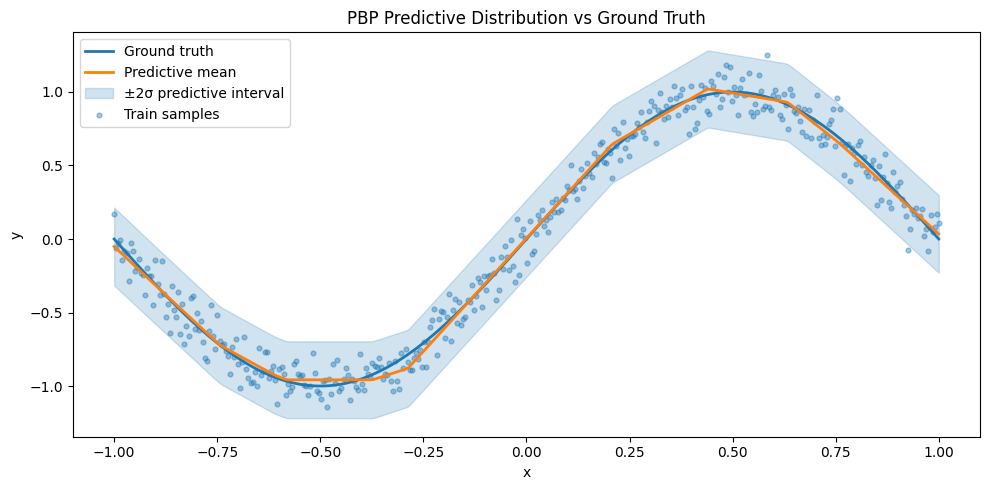

In [21]:
x_plot = x_val.squeeze()
mean_plot = m.squeeze()
std_plot = np.sqrt(np.maximum(v + v_noise, 0))

plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_val.squeeze(), label="Ground truth", linewidth=2)
plt.plot(x_plot, mean_plot, label="Predictive mean", linewidth=2)
plt.fill_between(
    x_plot,
    mean_plot - 2 * std_plot,
    mean_plot + 2 * std_plot,
    color="tab:blue",
    alpha=0.2,
    label="±2σ predictive interval",
)
plt.scatter(
    x_train.squeeze(), y_train.squeeze(), s=12, alpha=0.4, label="Train samples"
)
plt.title("PBP Predictive Distribution vs Ground Truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()